## **Data visualization**

In [84]:
import pandas as pd

In [85]:
df = pd.read_csv("U.S._Chronic_Disease_Indicators.csv")

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

In [87]:
import matplotlib.pyplot as plt

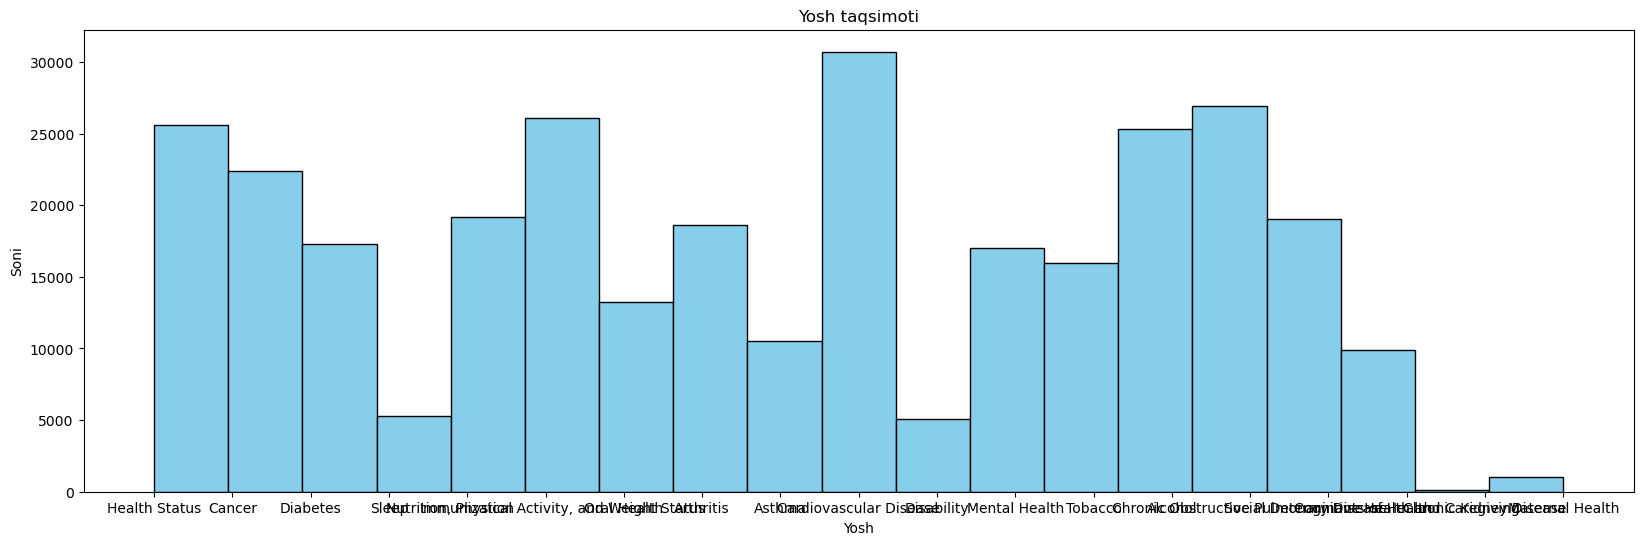

In [91]:
plt.figure(figsize=(20,6))  # Figura o'chami
plt.hist(df['Topic'],bins=19, color='skyblue',edgecolor='black')  # Figure turi histogram  
plt.title('Yosh taqsimoti')
plt.xlabel('Yosh')
plt.ylabel('Soni')
 
plt.show()

### **Deleting columns that has NaN values and columns that have no predictive features** 

In [75]:
df = df.dropna(axis=1)
df = df.drop(columns =["StratificationCategory1", "Stratification1", "LocationID", "TopicID", "QuestionID", "DataValueTypeID", "StratificationCategoryID1", "StratificationID1", "LocationAbbr"])

In [76]:
df.sample(10)

,YearStart,YearEnd,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType
135888,2020,2020,Idaho,NVSS,Asthma,"Asthma mortality among all people, underlying ...","cases per 100,000",Crude Rate
19717,2019,2019,Arizona,BRFSS,Arthritis,Work limitation due to arthritis among adults ...,%,Age-adjusted Prevalence
259813,2021,2021,Texas,BRFSS,"Nutrition, Physical Activity, and Weight Status",Consumed vegetables less than one time daily a...,%,Age-adjusted Prevalence
304682,2022,2022,Washington,BRFSS,"Nutrition, Physical Activity, and Weight Status",Obesity among adults,%,Crude Prevalence
296911,2022,2022,Tennessee,BRFSS,Tobacco,Current cigarette smoking among adults,%,Crude Prevalence
161948,2020,2020,Oregon,BRFSS,Immunization,Influenza vaccination among adults 18â€“64 who...,%,Crude Prevalence
224537,2021,2021,Nevada,BRFSS,Health Status,Average recent physically unhealthy days among...,Number,Age-adjusted Mean
110861,2020,2020,Colorado,PRAMS,Mental Health,Postpartum depressive symptoms among women wit...,%,Crude Prevalence
178873,2020,2020,Wisconsin,BRFSS,Mental Health,Average mentally unhealthy days among adults,Number,Age-adjusted Mean
275398,2022,2022,Nebraska,BRFSS,Alcohol,Binge drinking prevalence among adults,%,Crude Prevalence


### **Defining target column**

In [77]:
df["Topic"].nunique()

19

## **Encoding**

In [78]:
from sklearn.preprocessing import LabelEncoder

def encoding(df):
    encoder = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == "object":
            if df[col].nunique() <= 5:
                dummies = pd.get_dummies(df[col], prefix = col, dtype=int)
                df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
            else:
                 df[col] = encoder.fit_transform(df[col])
    return df

In [79]:
df = encoding(df)

In [80]:
df.sample(10)

,YearStart,YearEnd,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType
224624,2021,2021,32,3,1,93,0,7
206952,2021,2021,20,13,18,33,0,7
144998,2020,2020,26,3,15,4,0,2
33528,2019,2019,7,3,9,2,0,2
156696,2020,2020,39,3,0,11,0,7
204873,2021,2021,9,3,10,8,1,1
193641,2021,2021,9,4,4,57,3,3
17077,2019,2019,3,3,0,11,0,2
96443,2019,2019,43,3,1,49,0,7
237902,2021,2021,36,13,13,34,0,7


## **RandomForestClassifier**

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 

x = df.drop("Topic", axis=1)
y = df["Topic"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

In [82]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5036
           1       1.00      1.00      1.00      3720
           2       1.00      1.00      1.00      2073
           3       1.00      1.00      1.00      4448
           4       1.00      1.00      1.00      6181
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00      5540
           7       1.00      1.00      1.00      1961
           8       1.00      1.00      1.00      3451
           9       1.00      1.00      1.00      1000
          10       1.00      1.00      1.00      5077
          11       1.00      1.00      1.00      3762
          12       1.00      1.00      1.00       214
          13       1.00      1.00      1.00      3383
          14       1.00      1.00      1.00      5233
          15       1.00      1.00      1.00      2706
          16       1.00      1.00      1.00      1007
          17       1.00    

In [83]:
from sklearn.model_selection import cross_val_score
cross_val_score(rfc, x, y, cv=5) 

array([0.72381676, 0.93582135, 0.8672283 , 0.9293857 , 0.77470369])